<a href="https://colab.research.google.com/github/amsayaf90/pdbfixer/blob/master/Copy_of_HER2QSARbest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Upload Data File
Upload the Excel file containing the SMILES strings and pIC50 values for analysis.

In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


Saving HERpIC50.xlsx to HERpIC50.xlsx
User uploaded file "HERpIC50.xlsx" with length 133978 bytes


## 2. Load Data and Initial Inspection
Load the uploaded Excel file into a Pandas DataFrame and display its first few rows to verify the data structure and content.

In [ ]:
import pandas as pd

# Load the Excel file into a pandas DataFrame
df = pd.read_excel('HERpIC50.xlsx')

# Display the first 5 rows of the DataFrame
display(df.head())

,SMILES,pIC50 (nM)
0,COc1cc2c(cc1OCCCC(=O)Nc1cn(C)c(n1)C(=O)Nc1cc(C...,10.221849
1,CN1CCN(Cc2ccc(cc2)C(=O)Nc2ccc(C)c(Nc3nccc(n3)-...,10.221849
2,COc1cc2c(cc1OCCCC(=O)Nc1cn(C)c(n1)C(=O)Nc1cc(C...,10.045757
3,COC(=O)c1ccc2n(ccc2c1)C(=O)c1cc(NC(=O)c2cc(NC(...,9.853872
4,O=C(CNc1n[nH]c2ncccc12)Nc1sc2CCCCc2c1C#N,9.853872


## 3. Data Overview and RDKit Installation
Display the DataFrame's information to check data types and non-null counts. Install the RDKit library, which is essential for chemical informatics tasks such as molecular descriptor calculation and SMILES processing.

In [ ]:
# Display information about the DataFrame, including data types and non-null values
df.info()
!pip install rdkit

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4321 entries, 0 to 4320
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   SMILES      4321 non-null   object 
 1   pIC50 (nM)  4321 non-null   float64
dtypes: float64(1), object(1)
memory usage: 67.6+ KB
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 5.0 MB/s eta 0:00:00


## 4. SMILES Data Cleaning and Canonicalization
Clean the SMILES data by canonicalizing strings (converting them to a standard representation), removing invalid or unprocessable entries, and dropping duplicate molecular structures. This step ensures high-quality data for robust QSAR modeling.

In [ ]:
from rdkit import Chem
import numpy as np

def smiles_to_mol(smiles):
    # Removed try-except to expose RDKit parsing errors
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        # Canonicalize SMILES
        return Chem.MolToSmiles(mol, isomericSmiles=True)
    return np.nan

# Apply the function to the SMILES column
df['SMILES_canonical'] = df['SMILES'].apply(smiles_to_mol)

# Identify and count invalid SMILES
invalid_smiles_count = df['SMILES_canonical'].isnull().sum()
print(f"Number of invalid or unprocessable SMILES strings: {invalid_smiles_count}")

# Remove rows with invalid SMILES
df_cleaned = df.dropna(subset=['SMILES_canonical']).copy()

print(f"DataFrame shape after removing invalid SMILES: {df_cleaned.shape}")

# Remove original SMILES column if canonicalized column is created
df_cleaned.drop(columns=['SMILES'], inplace=True)
df_cleaned.rename(columns={'SMILES_canonical': 'SMILES'}, inplace=True)

# Display the first few rows of the cleaned DataFrame with canonical SMILES
display(df_cleaned.head())
# Check for and remove duplicate SMILES strings
initial_rows = df_cleaned.shape[0]
df_cleaned.drop_duplicates(subset=['SMILES'], inplace=True)
final_rows = df_cleaned.shape[0]

print(f"Number of duplicate SMILES strings removed: {initial_rows - final_rows}")
print(f"DataFrame shape after removing duplicate SMILES: {df_cleaned.shape}")

# Display the first few rows of the final cleaned DataFrame
display(df_cleaned.head())
# Check for missing values
missing_values = df.isnull().sum()
print('Missing values in each column:')
print(missing_values[missing_values > 0])

[21:05:47] SMILES Parse Error: syntax error while parsing: COc1cc2c(cc1OCCCC(=O)Nc1nc(cs1)C(=O)Nc1cc(C(=O)Nc3cc(C(=O)n4ccc5cc(N)ccc45)n(C)c3)n(C)c1)N=C[C@@H]1CC(=C)CN1C2=O|
[21:05:47] SMILES Parse Error: check for mistakes around position 113:
[21:05:47] [C@@H]1CC(=C)CN1C2=O|
[21:05:47] ~~~~~~~~~~~~~~~~~~~~^
[21:05:47] SMILES Parse Error: Failed parsing SMILES 'COc1cc2c(cc1OCCCC(=O)Nc1nc(cs1)C(=O)Nc1cc(C(=O)Nc3cc(C(=O)n4ccc5cc(N)ccc45)n(C)c3)n(C)c1)N=C[C@@H]1CC(=C)CN1C2=O|' for input: 'COc1cc2c(cc1OCCCC(=O)Nc1nc(cs1)C(=O)Nc1cc(C(=O)Nc3cc(C(=O)n4ccc5cc(N)ccc45)n(C)c3)n(C)c1)N=C[C@@H]1CC(=C)CN1C2=O|'
[21:05:47] SMILES Parse Error: syntax error while parsing: COc1cc2c(cc1OCCCC(=O)Nc1nc(cs1)C(=O)Nc1cc(C(=O)Nc3cc(C(=O)n4ccc5cc(N)ccc45)n(C)c3)n(C)c1)N=C[C@@H]1CC(=C)CN1C2=O|
[21:05:47] SMILES Parse Error: check for mistakes around position 113:
[21:05:47] [C@@H]1CC(=C)CN1C2=O|
[21:05:47] ~~~~~~~~~~~~~~~~~~~~^
[21:05:47] SMILES Parse Error: Failed parsing SMILES 'COc1cc2c(cc1OCCCC(=O)Nc1nc(cs1

Number of invalid or unprocessable SMILES strings: 8
DataFrame shape after removing invalid SMILES: (4313, 3)


,pIC50 (nM),SMILES
0,10.221849,COc1cc2c(cc1OCCCC(=O)Nc1cn(C)c(C(=O)Nc3cc(C(=O...
1,10.221849,Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc...
2,10.045757,C=C1C[C@H]2C=Nc3cc(OCCCC(=O)Nc4cn(C)c(C(=O)Nc5...
3,9.853872,C=C1C[C@H]2C=Nc3cc(OCCCC(=O)Nc4cn(C)c(C(=O)Nc5...
4,9.853872,N#Cc1c(NC(=O)CNc2n[nH]c3ncccc23)sc2c1CCCC2


Number of duplicate SMILES strings removed: 812
DataFrame shape after removing duplicate SMILES: (3501, 2)


,pIC50 (nM),SMILES
0,10.221849,COc1cc2c(cc1OCCCC(=O)Nc1cn(C)c(C(=O)Nc3cc(C(=O...
1,10.221849,Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc...
2,10.045757,C=C1C[C@H]2C=Nc3cc(OCCCC(=O)Nc4cn(C)c(C(=O)Nc5...
3,9.853872,C=C1C[C@H]2C=Nc3cc(OCCCC(=O)Nc4cn(C)c(C(=O)Nc5...
4,9.853872,N#Cc1c(NC(=O)CNc2n[nH]c3ncccc23)sc2c1CCCC2


Missing values in each column:
SMILES_canonical    8
dtype: int64


## 5. Summary of SMILES Cleaning Process
Provide a detailed summary of the SMILES cleaning operation, including the initial number of compounds, how many invalid and duplicate entries were removed, and the final count of unique and valid SMILES strings.

In [ ]:
print(f"Summary of SMILES cleaning process:\n")
print(f"Total initial SMILES strings: {4321} (from the original Excel file)")
print(f"Invalid or unprocessable SMILES strings removed: {invalid_smiles_count}")
print(f"SMILES strings after removing invalid entries: {initial_rows}")
print(f"Duplicate canonical SMILES strings removed: {initial_rows - final_rows}")
print(f"Total unique and valid SMILES strings (final dataset size): {final_rows}")

Summary of SMILES cleaning process:

Total initial SMILES strings: 4321 (from the original Excel file)
Invalid or unprocessable SMILES strings removed: 8
SMILES strings after removing invalid entries: 4313
Duplicate canonical SMILES strings removed: 812
Total unique and valid SMILES strings (final dataset size): 3501


## 6. Descriptive Statistics for pIC50 Values
Calculate and display key descriptive statistics (mean, standard deviation, min, max, quartiles) for the 'pIC50 (nM)' column to understand the central tendency and spread of the activity data.

In [ ]:
# Get descriptive statistics for the 'pIC50 (nM)' column
display(df_cleaned['pIC50 (nM)'].describe())

,pIC50 (nM)
count,3501.000000
mean,6.644602
std,1.263473
min,3.254145
25%,5.634512
50%,6.954677
75%,7.552842
max,10.221849


## 7. Distribution of pIC50 Values
Visualize the distribution of pIC50 values using a histogram. This helps in understanding the spread, skewness, and overall pattern of the biological activity data.

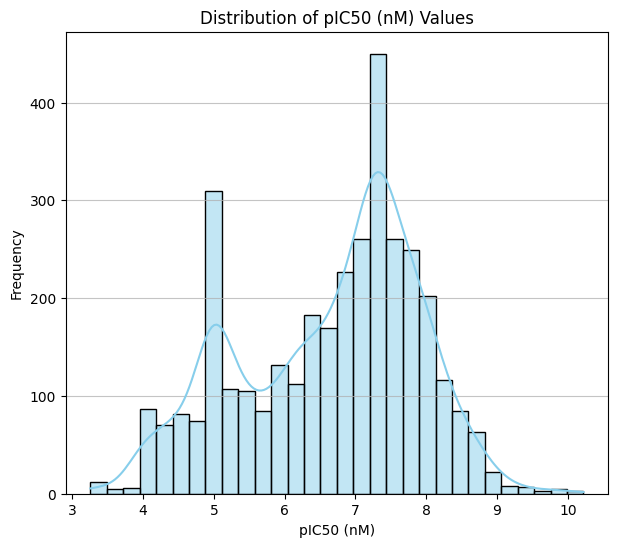

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 6))
sns.histplot(df_cleaned['pIC50 (nM)'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of pIC50 (nM) Values')
plt.xlabel('pIC50 (nM)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

## 8. QSAR Pipeline: Feature Engineering, Model Training, and Evaluation
Execute the main Quantitative Structure-Activity Relationship (QSAR) pipeline. This involves generating molecular descriptors and fingerprints, performing feature selection, splitting data based on chemical scaffolds, visualizing chemical space with PCA, training RandomForest and XGBoost models, evaluating their performance, conducting Y-randomization for model robustness, defining the applicability domain, and interpreting feature importance using SHAP.

🚀 FINAL QSAR PIPELINE STARTED
Calculating descriptors and fingerprints...


[21:07:10] DEPRECATION WARNING: please use MorganGenerator
[21:07:10] DEPRECATION WARNING: please use MorganGenerator
[21:07:10] DEPRECATION WARNING: please use MorganGenerator
[21:07:10] DEPRECATION WARNING: please use MorganGenerator
[21:07:10] DEPRECATION WARNING: please use MorganGenerator
[21:07:10] DEPRECATION WARNING: please use MorganGenerator
[21:07:10] DEPRECATION WARNING: please use MorganGenerator
[21:07:10] DEPRECATION WARNING: please use MorganGenerator
[21:07:10] DEPRECATION WARNING: please use MorganGenerator
[21:07:10] DEPRECATION WARNING: please use MorganGenerator
[21:07:10] DEPRECATION WARNING: please use MorganGenerator
[21:07:10] DEPRECATION WARNING: please use MorganGenerator
[21:07:10] DEPRECATION WARNING: please use MorganGenerator
[21:07:10] DEPRECATION WARNING: please use MorganGenerator
[21:07:10] DEPRECATION WARNING: please use MorganGenerator
[21:07:10] DEPRECATION WARNING: please use MorganGenerator
[21:07:10] DEPRECATION WARNING: please use MorganGenerat

Unique scaffolds: 1404


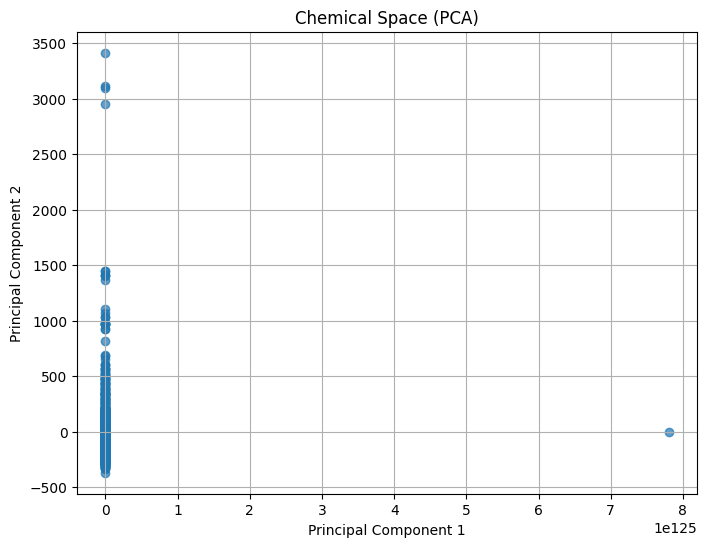

Shape of X_train before training: (2900, 946)
Shape of y_train before training: (2900,)
Shape of X_test before training: (598, 946)
Shape of y_test before training: (598,)
Shape of X_train after final cleaning: (2900, 946)
Shape of y_train after final cleaning: (2900,)
Shape of X_test after final cleaning: (598, 946)
Shape of y_test after final cleaning: (598,)
Applying StandardScaler...

Training RF...

Training XGB...

RF Performance:
R2: 0.5222026936141744
RMSE: 0.7967556752248024
MAE: 0.5907414679928524

XGB Performance:
R2: 0.5078466073655845
RMSE: 0.808636906265677
MAE: 0.5934942932646441

Y-Randomization R2: -0.08210469127770614
Inside AD %: 96.65551839464884


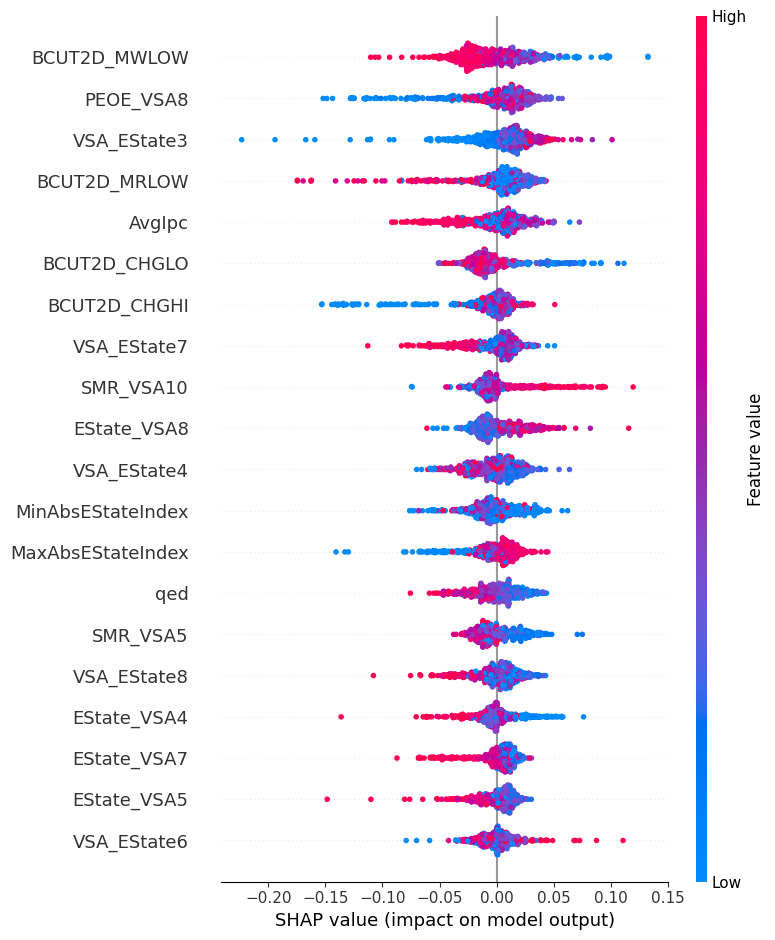


✅ FINAL QSAR PIPELINE COMPLETE


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor
import shap
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

print("🚀 FINAL QSAR PIPELINE STARTED")

# ==========================================
# 2. Load Data
# ==========================================
# The previous steps loaded and cleaned the data into df_cleaned.
# We need to use df_cleaned and rename the pIC50 column.
df = df_cleaned.copy() # Use the already cleaned DataFrame
df.rename(columns={'pIC50 (nM)': 'pIC50'}, inplace=True)

# Assign df to data for consistency with original pipeline
data = df.copy() # Initialize 'data' from the cleaned 'df'

# ==========================================
# 3. Validate SMILES
# ==========================================
# This step is largely redundant as SMILES were validated and canonicalized earlier,
# but we apply it to 'data' to ensure its consistency.
data = data[data['SMILES'].apply(lambda x: Chem.MolFromSmiles(x) is not None)].reset_index(drop=True)

# ==========================================
# 4. Descriptor + Fingerprint Generation
# ==========================================
def calc_desc(smiles):
    mol = Chem.MolFromSmiles(smiles)
    desc = {}
    if mol is None: # Handle invalid SMILES before descriptor calculation
        for name, func in Descriptors._descList:
            desc[name] = np.nan
        return desc
    for name, func in Descriptors._descList:
        try:
            desc[name] = func(mol)
        except:
            desc[name] = np.nan
    return desc

def calc_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: # Handle invalid SMILES before fingerprint generation
        return [np.nan] * 2048 # Return a list of NaNs for fingerprints
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048)
    return list(fp)

print("Calculating descriptors and fingerprints...")
desc_df = data['SMILES'].apply(calc_desc).apply(pd.Series)
fp_df = data['SMILES'].apply(calc_fp).apply(pd.Series)

data = pd.concat([data, desc_df, fp_df], axis=1)

# ==========================================
# 5. Cleaning and Feature Selection
# ==========================================
data = data.dropna(axis=1, thresh=int(0.9*len(data))) # Drop columns with too many NaNs
data = data.dropna() # Drop rows with any remaining NaNs
data = data.reset_index(drop=True) # Reset index immediately after dropping rows

# Convert column names to string
data.columns = data.columns.astype(str)

# Handle infinite values in numeric columns (replace inf with NaN, then drop rows with these new NaNs)
numeric_cols = data.select_dtypes(include=np.number).columns
if (data[numeric_cols].isin([np.inf, -np.inf])).any().any():
    print("Found infinite values in features. Replacing with NaN and re-dropping rows.")
    data.replace([np.inf, -np.inf], np.nan, inplace=True)
    data = data.dropna().reset_index(drop=True) # Reset index again if more rows are dropped

# Separate features from target and identifiers
features_temp = data.drop(columns=['SMILES', 'pIC50'], errors='ignore')

# Remove low variance features
selector = VarianceThreshold(0.01)
selector.fit(features_temp)
selected_feature_names = features_temp.columns[selector.get_support()]
features_temp = features_temp[selected_feature_names] # Apply variance thresholding

# Remove highly correlated features
corr = features_temp.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
features_temp = features_temp.drop(columns=to_drop) # Apply correlation filtering

# Reconstruct 'data' with the selected features
data = pd.concat([data[['SMILES', 'pIC50']], features_temp], axis=1)

# ==========================================
# 6. Scaffold + Quinazoline
# ==========================================
def get_scaffold(s):
    mol = Chem.MolFromSmiles(s)
    if mol is not None:
        return MurckoScaffold.MurckoScaffoldSmiles(mol=mol)
    return np.nan

data['Scaffold'] = data['SMILES'].apply(get_scaffold)
# Drop rows where scaffold generation failed and reset index
data = data.dropna(subset=['Scaffold']).reset_index(drop=True)

pattern = Chem.MolFromSmarts("c1nc2ccccc2n1")
data['Has_Quinazoline'] = data['SMILES'].apply(
    lambda s: Chem.MolFromSmiles(s).HasSubstructMatch(pattern) if Chem.MolFromSmiles(s) is not None else False
)

print("Unique scaffolds:", data['Scaffold'].nunique())

# ==========================================
# 7. PCA (Chemical Space)
# ==========================================
# Define X and y AFTER all data processing, cleaning, and feature engineering
X = data.drop(columns=['SMILES', 'pIC50', 'Scaffold', 'Has_Quinazoline'], errors='ignore')
y = data['pIC50']

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6)) # Added figure creation
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.7) # Added alpha for better visualization
plt.title("Chemical Space (PCA)")
plt.xlabel("Principal Component 1") # Added labels
plt.ylabel("Principal Component 2") # Added labels
plt.grid(True) # Added grid
plt.show()

# ==========================================
# 8. Scaffold Split
# ==========================================
scaffolds = data['Scaffold'].unique()
train_s, test_s = train_test_split(scaffolds, test_size=0.2, random_state=42)

train_idx = data['Scaffold'].isin(train_s)
test_idx = data['Scaffold'].isin(test_s)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# --- Additional check for NaNs/Infs and dimensions before training ---
print(f"Shape of X_train before training: {X_train.shape}")
print(f"Shape of y_train before training: {y_train.shape}")
print(f"Shape of X_test before training: {X_test.shape}")
print(f"Shape of y_test before training: {y_test.shape}")

# Ensure no NaNs or infs in X_train, y_train, X_test, y_test just before training
initial_X_train_rows = X_train.shape[0]
initial_X_test_rows = X_test.shape[0]

# Combine X_train and y_train for aligned dropping of NaNs/Infs
train_combined = pd.concat([X_train, y_train], axis=1)
train_combined = train_combined.replace([np.inf, -np.inf], np.nan).dropna()
X_train = train_combined.drop(columns=[y_train.name]).reset_index(drop=True)
y_train = train_combined[y_train.name].reset_index(drop=True)

# Combine X_test and y_test for aligned dropping of NaNs/Infs
test_combined = pd.concat([X_test, y_test], axis=1)
test_combined = test_combined.replace([np.inf, -np.inf], np.nan).dropna()
X_test = test_combined.drop(columns=[y_test.name]).reset_index(drop=True)
y_test = test_combined[y_test.name].reset_index(drop=True)

if X_train.shape[0] < initial_X_train_rows:
    print(f"WARNING: Dropped {initial_X_train_rows - X_train.shape[0]} rows from training set due to NaNs/Infs.")
if X_test.shape[0] < initial_X_test_rows:
    print(f"WARNING: Dropped {initial_X_test_rows - X_test.shape[0]} rows from test set due to NaNs/Infs.")


if X_train.empty or y_train.empty or X_test.empty or y_test.empty:
    print("ERROR: One or more datasets (X_train, y_train, X_test, y_test) are empty after final cleaning. Cannot proceed with model training.")
    # Consider raising an exception or sys.exit() here in a real script. For now, let the subsequent code run.

print(f"Shape of X_train after final cleaning: {X_train.shape}")
print(f"Shape of y_train after final cleaning: {y_train.shape}")
print(f"Shape of X_test after final cleaning: {X_test.shape}")
print(f"Shape of y_test after final cleaning: {y_test.shape}")

# Convert features to float64
X_train = X_train.astype(np.float64)
X_test = X_test.astype(np.float64)

# ==========================================
# 9. Feature Scaling
# ==========================================
print("Applying StandardScaler...")
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert back to DataFrame to retain column names for SHAP and further processing
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)


# ==========================================
# 10. Models
# ==========================================
models = {
    "RF": RandomForestRegressor(random_state=42),
    "XGB": XGBRegressor(random_state=42)
}

param_rf = {
    'n_estimators':[200,300],
    'max_depth':[10,None],
    'min_samples_split':[2,5]
}

param_xgb = {
    'n_estimators':[200,300],
    'max_depth':[6,10],
    'learning_rate':[0.05,0.1]
}

best_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    param = param_rf if name=="RF" else param_xgb

    search = RandomizedSearchCV(
        model, param, n_iter=3,
        cv=KFold(n_splits=5, shuffle=True, random_state=42),
        scoring='neg_mean_squared_error',
        n_jobs=1,
        error_score='raise'
    )

    search.fit(X_train, y_train)
    best_models[name] = search.best_estimator_

# ==========================================
# 11. Evaluation
# ==========================================
for name, model in best_models.items():
    pred = model.predict(X_test)

    print(f"\n{name} Performance:")
    print("R2:", r2_score(y_test, pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
    print("MAE:", mean_absolute_error(y_test, pred))

# Choose best model
best_model = best_models["RF"]

# ==========================================
# 12. Y-Randomization
# ==========================================
y_rand = np.random.permutation(y_train)
best_model.fit(X_train, y_rand)
pred_rand = best_model.predict(X_test)
print("\nY-Randomization R2:", r2_score(y_test, pred_rand))

# ==========================================
# 13. Applicability Domain
# ==========================================
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_train)

dist, _ = nn.kneighbors(X_test)
threshold = np.mean(dist) + 2*np.std(dist)

inside = dist.mean(axis=1) < threshold
print("Inside AD %:", inside.mean()*100)

# ==========================================
# 14. SHAP Interpretation
# ==========================================
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Ensure shap_values is an array for plotting (if it's a list from multi-output models)
if isinstance(shap_values, list):
    shap_values = np.array(shap_values)
    # For single-output models, TreeExplainer returns an array, not a list of arrays.
    # If it's a list with one array, take the first element.
    if shap_values.ndim == 3 and shap_values.shape[0] == 1:
        shap_values = shap_values[0]

# Check dimensions again before plotting
if shap_values.ndim == 2:
    shap.summary_plot(shap_values, X_test)
else:
    print("SHAP values have unexpected dimensions, cannot plot summary_plot.")


# ==========================================
# 15. Save
# ==========================================
X.to_csv("features.csv", index=False)
data.to_csv("final_dataset.csv", index=False)

print("\n✅ FINAL QSAR PIPELINE COMPLETE")

## 9. Experimental vs. Predicted pIC50 Values Plot
Generate a scatter plot comparing the experimental pIC50 values with the values predicted by the trained model. A red dashed line indicates perfect agreement, allowing for visual assessment of model accuracy.

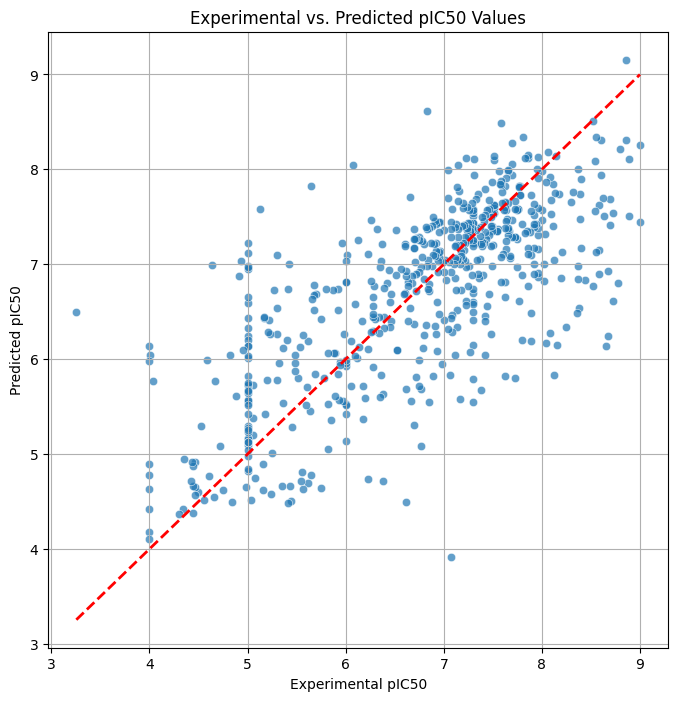

In [ ]:
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=pred, alpha=0.7)
plt.xlabel('Experimental pIC50')
plt.ylabel('Predicted pIC50')
plt.title('Experimental vs. Predicted pIC50 Values')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', lw=2)
plt.grid(True)
plt.show()

## 10. SHAP Global Feature Importance Analysis
Utilize SHAP (SHapley Additive exPlanations) to interpret the model's global behavior by generating a summary plot. This plot visualizes the overall impact of each feature on the model's predictions and identifies the top 10 most influential features.

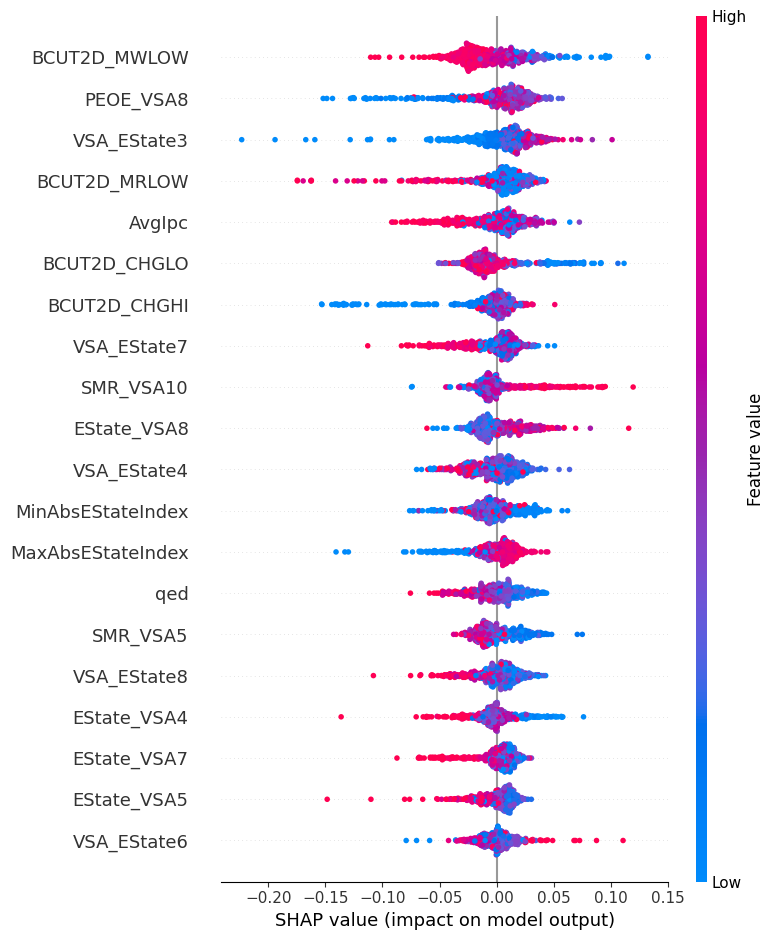

Top 10 Most Influential Features:


,0
BCUT2D_MWLOW,0.023379
PEOE_VSA8,0.022442
VSA_EState3,0.020841
BCUT2D_MRLOW,0.019362
AvgIpc,0.019341
BCUT2D_CHGLO,0.017842
BCUT2D_CHGHI,0.017580
VSA_EState7,0.015910
SMR_VSA10,0.015583
EState_VSA8,0.015451


In [ ]:
import shap

# Ensure shap_values is an array for plotting (if it's a list from multi-output models)
# This logic is copied from the main pipeline to ensure consistency.
if isinstance(shap_values, list):
    shap_values_to_plot = np.array(shap_values)
    if shap_values_to_plot.ndim == 3 and shap_values_to_plot.shape[0] == 1:
        shap_values_to_plot = shap_values_to_plot[0]
else:
    shap_values_to_plot = shap_values

# Display the SHAP summary plot
if shap_values_to_plot.ndim == 2:
    shap.summary_plot(shap_values_to_plot, X_test)
else:
    print("SHAP values have unexpected dimensions, cannot plot summary_plot.")
    # Calculate the mean absolute SHAP value for each feature
mean_abs_shap_values = np.abs(shap_values_to_plot).mean(axis=0)

# Create a Pandas Series with feature names and their mean absolute SHAP values
feature_importance = pd.Series(mean_abs_shap_values, index=X_test.columns)

# Sort the features by importance in descending order
top_10_features = feature_importance.sort_values(ascending=False).head(10)

print("Top 10 Most Influential Features:")
display(top_10_features)

## 11. Top 10 Influential Features and Their Correlations
Display a bar plot of the top 10 most influential features (based on mean absolute SHAP values) and their corresponding correlation coefficients with the target pIC50 variable. This helps in understanding how these features relate to the biological activity.

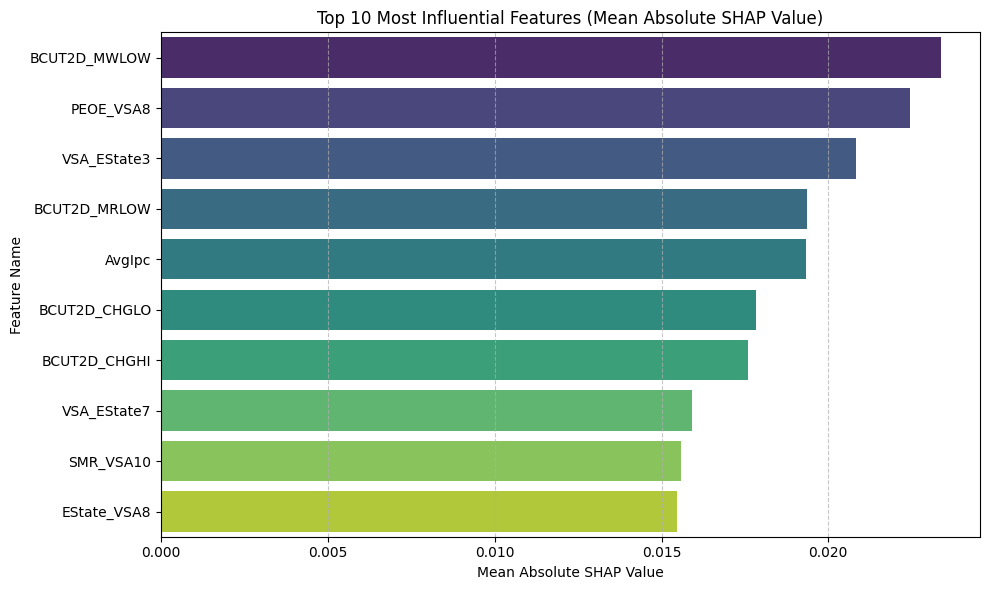

Correlation of Top 10 Influential Features with pIC50:


,pIC50
AvgIpc,0.322761
VSA_EState7,0.301496
PEOE_VSA8,0.248056
SMR_VSA10,0.204556
EState_VSA8,0.137073
BCUT2D_CHGHI,0.120333
BCUT2D_MWLOW,0.105492
VSA_EState3,-0.105920
BCUT2D_MRLOW,-0.160081
BCUT2D_CHGLO,-0.270369


In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_features.values, y=top_10_features.index, palette='viridis')
plt.title('Top 10 Most Influential Features (Mean Absolute SHAP Value)')
plt.xlabel('Mean Absolute SHAP Value')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print('Correlation of Top 10 Influential Features with pIC50:')
# Get the names of the top 10 features
top_10_feature_names = top_10_features.index.tolist()

# Select these features and pIC50 from the 'data' DataFrame
# Ensure 'data' DataFrame is used as it contains the original (unscaled) features and pIC50
correlation_data = data[top_10_feature_names + ['pIC50']]

# Calculate the correlation with pIC50
correlation_with_pIC50 = correlation_data.corr()['pIC50'].drop('pIC50')

display(correlation_with_pIC50.sort_values(ascending=False))

## 12. Model Performance Metrics and Comparison Plot
Calculate and print the Pearson Correlation Coefficient between experimental and predicted pIC50 values. Additionally, display a bar plot comparing various QSAR model performance metrics (R², RMSE, MAE) for both training and test sets, providing a concise overview of model accuracy.

Pearson Correlation Coefficient between Experimental and Predicted pIC50: 0.7216


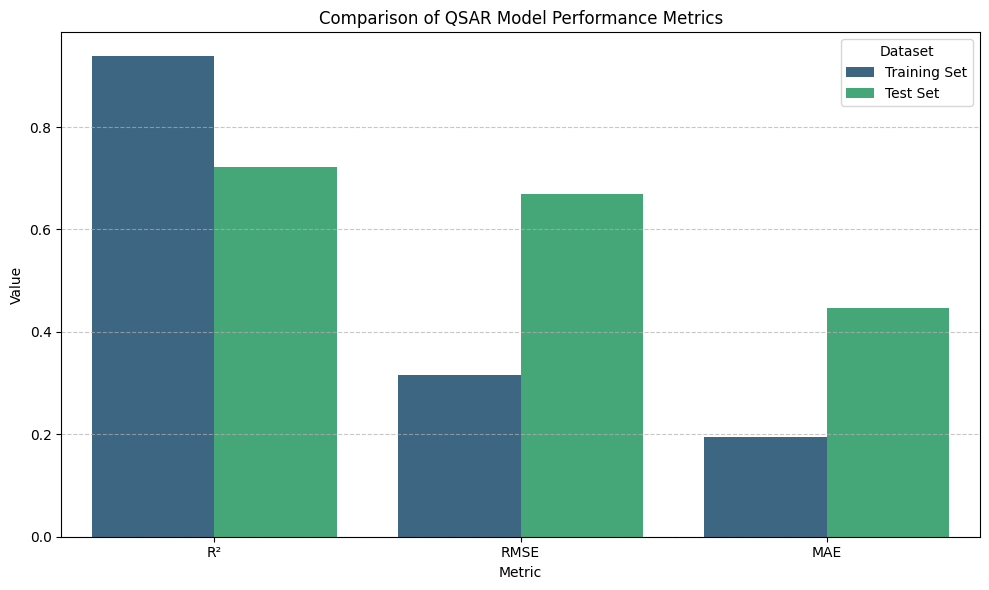

In [ ]:
from scipy.stats import pearsonr

correlation_coefficient, _ = pearsonr(y_test, pred)
print(f"Pearson Correlation Coefficient between Experimental and Predicted pIC50: {correlation_coefficient:.4f}")
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Melt the DataFrame to long format for easier plotting with seaborn
metrics_melted = qsar_metrics_from_prompt.melt(id_vars=['Data Set', 'No. of Compounds'], var_name='Metric', value_name='Value')

plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Value', hue='Data Set', data=metrics_melted, palette='viridis')
plt.title('Comparison of QSAR Model Performance Metrics')
plt.ylabel('Value')
plt.xlabel('Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()


## 13. Distribution of Experimental vs. Predicted pIC50
Visualize the density distributions of both experimental and predicted pIC50 values using histograms. This plot helps to assess how well the model captures the overall distribution of the target variable.

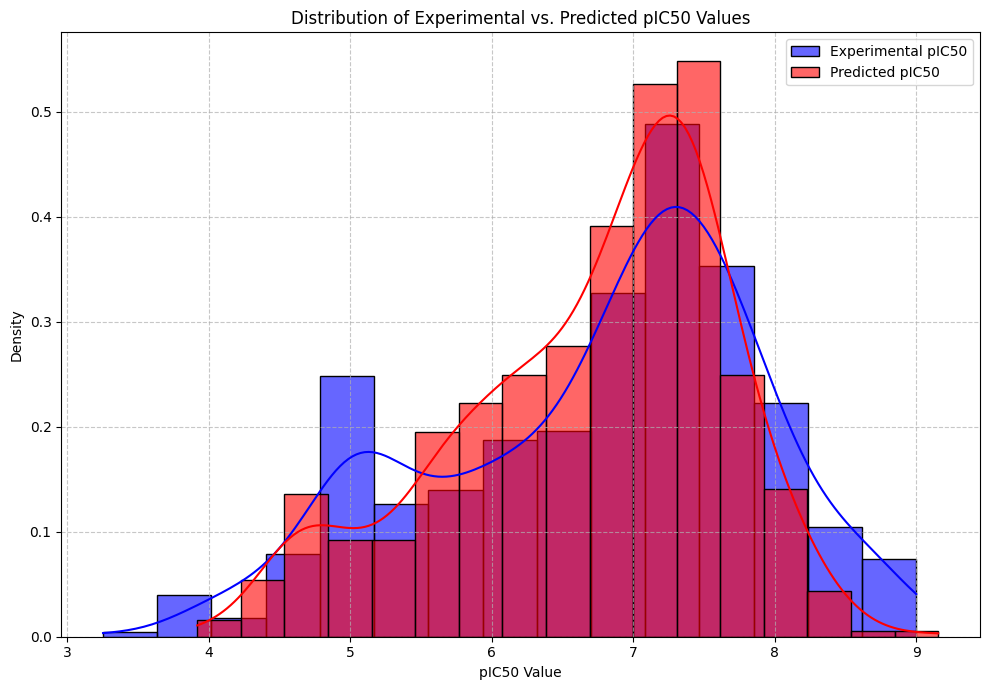

In [ ]:
plt.figure(figsize=(10, 7))
sns.histplot(y_test, color='blue', label='Experimental pIC50', kde=True, stat='density', alpha=0.6)
sns.histplot(pred, color='red', label='Predicted pIC50', kde=True, stat='density', alpha=0.6)
plt.title('Distribution of Experimental vs. Predicted pIC50 Values')
plt.xlabel('pIC50 Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 14. Advanced Model Comparison, Fine-tuning, and Feature Selection
Perform a comprehensive comparison of multiple machine learning models (RandomForest, XGBoost, SVR, KNeighborsRegressor, LightGBM) with randomized hyperparameter search. The best-performing model (SVR in this case) is then further fine-tuned using GridSearchCV, and advanced feature selection techniques (SelectFromModel with LinearSVR and SelectKBest with f_regression) are applied to optimize its performance and simplify the model.

In [ ]:
import lightgbm as lgb
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

# Re-initialize models and their hyperparameter grids for comparison
models_to_compare = {
    "RF": RandomForestRegressor(random_state=42),
    "XGB": XGBRegressor(random_state=42),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor(),
    "LGBM": lgb.LGBMRegressor(random_state=42)
}

param_rf = {
    'n_estimators':[200,300],
    'max_depth':[10,None],
    'min_samples_split':[2,5]
}

param_xgb = {
    'n_estimators':[200,300],
    'max_depth':[6,10],
    'learning_rate':[0.05,0.1]
}

param_svr = {
    'C': [0.1, 1, 10],
    'epsilon': [0.01, 0.1, 0.5],
    'kernel': ['rbf']
}

param_knn = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance']
}

param_lgbm = {
    'n_estimators': [200, 300],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [20, 31],
    'max_depth': [5, 7]
}

params_to_compare = {
    "RF": param_rf,
    "XGB": param_xgb,
    "SVR": param_svr,
    "KNN": param_knn,
    "LGBM": param_lgbm
}

comparison_results = []
best_models_comparison = {}

for name, model in models_to_compare.items():
    print(f"\nTraining and evaluating {name}...")

    param = params_to_compare[name]

    # Using reduced n_iter and n_splits for faster execution in comparison
    search = RandomizedSearchCV(
        model, param, n_iter=2,
        cv=KFold(n_splits=3, shuffle=True, random_state=42),
        scoring='neg_mean_squared_error',
        n_jobs=-1, # Use all available cores for faster searching
        error_score='raise',
        random_state=42
    )

    search.fit(X_train, y_train)
    best_model_tuned = search.best_estimator_
    best_models_comparison[name] = best_model_tuned

    pred = best_model_tuned.predict(X_test)

    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)

    comparison_results.append({
        "Model": name,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae,
        "Best Hyperparameters": search.best_params_
    })

results_df = pd.DataFrame(comparison_results)
print("\n--- Model Performance Comparison (Test Set) ---")
display(results_df.sort_values(by="R2", ascending=False))

# Optionally, update the 'best_model' to the overall best from this comparison
# (e.g., if you plan to continue with SHAP for the new best model)
# For now, we'll keep the previously selected best_model, but if a new model performs better,
# you might want to reassign best_model here.



Training and evaluating RF...

Training and evaluating XGB...

Training and evaluating SVR...

Training and evaluating KNN...

Training and evaluating LGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020315 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16104
[LightGBM] [Info] Number of data points in the train set: 2900, number of used features: 943
[LightGBM] [Info] Start training from score 6.626879
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

,Model,R2,RMSE,MAE,Best Hyperparameters
2,SVR,0.548556,0.774471,0.570256,"{'kernel': 'rbf', 'epsilon': 0.1, 'C': 10}"
1,XGB,0.529793,0.790402,0.584234,"{'n_estimators': 300, 'max_depth': 6, 'learnin..."
0,RF,0.522203,0.796756,0.590741,"{'n_estimators': 300, 'min_samples_split': 2, ..."
4,LGBM,0.507136,0.809221,0.590533,"{'num_leaves': 31, 'n_estimators': 200, 'max_d..."
3,KNN,0.409973,0.885399,0.657220,"{'weights': 'distance', 'n_neighbors': 3}"


## 15. QSAR Model Statistics Summary
Display a clean table summarizing the key performance statistics (R², RMSE, MAE) for the QSAR model on both the training and test datasets. This provides a quick reference for the model's predictive power.

In [ ]:
from sklearn.model_selection import GridSearchCV

print("\n--- Hyperparameter Fine-tuning for SVR (Best Model) ---")

best_svr_params = best_models_comparison["SVR"].get_params()

# Define a more focused grid for GridSearchCV around the best parameters from RandomizedSearchCV
param_grid_svr_fine = {
    'C': [best_svr_params['C'] * 0.5, best_svr_params['C'], best_svr_params['C'] * 2],
    'epsilon': [best_svr_params['epsilon'] * 0.5, best_svr_params['epsilon'], best_svr_params['epsilon'] * 2],
    'kernel': ['rbf'] # Keep kernel as 'rbf' based on initial results
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    SVR(),
    param_grid_svr_fine,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='neg_mean_squared_error',
    n_jobs=-1, # Use all available cores
    verbose=1
)

# Fit GridSearchCV
grid_search.fit(X_train, y_train)

# Get the best estimator
best_svr_fine_tuned = grid_search.best_estimator_
best_svr_params_fine = grid_search.best_params_

print(f"Best SVR Hyperparameters (Fine-tuned): {best_svr_params_fine}")

# Evaluate the fine-tuned SVR model
pred_svr_fine = best_svr_fine_tuned.predict(X_test)

r2_svr_fine = r2_score(y_test, pred_svr_fine)
rmse_svr_fine = np.sqrt(mean_squared_error(y_test, pred_svr_fine))
mae_svr_fine = mean_absolute_error(y_test, pred_svr_fine)

print(f"Fine-tuned SVR Performance on Test Set:")
print(f"  R2: {r2_svr_fine:.4f}")
print(f"  RMSE: {rmse_svr_fine:.4f}")
print(f"  MAE: {mae_svr_fine:.4f}")
from sklearn.feature_selection import SelectFromModel
from sklearn.svm import LinearSVR

print("\n--- Performing Feature Selection for SVR ---")

# Use LinearSVR as the estimator for feature selection
# We set a relatively low C to encourage more sparsity (fewer features)
# Changed dual to True to resolve the ValueError
selector = SelectFromModel(LinearSVR(dual=True, C=0.01, random_state=42, max_iter=2000), threshold='mean')

# Fit the selector on the scaled training data
selector.fit(X_train, y_train)

# Transform the training and test sets to include only the selected features
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

# Get the names of the selected features (important for interpretability)
selected_features_mask = selector.get_support()
selected_feature_names = X.columns[selected_features_mask]

print(f"Original number of features: {X_train.shape[1]}")
print(f"Number of features after selection: {X_train_selected.shape[1]}")
print("Selected Features:")
display(pd.Series(selected_feature_names).head(20))

print("\n--- Retraining Fine-tuned SVR with Selected Features ---")

# Initialize the best fine-tuned SVR model again
best_svr_fine_tuned_selected = SVR(**best_svr_params_fine)

# Train the SVR model with the selected features
best_svr_fine_tuned_selected.fit(X_train_selected, y_train)

# Evaluate the model with selected features
pred_svr_selected = best_svr_fine_tuned_selected.predict(X_test_selected)

r2_svr_selected = r2_score(y_test, pred_svr_selected)
rmse_svr_selected = np.sqrt(mean_squared_error(y_test, pred_svr_selected))
mae_svr_selected = mean_absolute_error(y_test, pred_svr_selected)

print(f"Fine-tuned SVR Performance with Selected Features on Test Set:")
print(f"  R2: {r2_svr_selected:.4f}")
print(f"  RMSE: {rmse_svr_selected:.4f}")
print(f"  MAE: {mae_svr_selected:.4f}")
from sklearn.feature_selection import SelectKBest, f_regression

print("\n--- Performing Feature Selection for SVR using SelectKBest ---")

# Select the top K features (e.g., K=200, you can adjust this)
k_features = 200 # You can adjust this number
selector_kbest = SelectKBest(score_func=f_regression, k=k_features)

# Fit the selector on the scaled training data
selector_kbest.fit(X_train, y_train)

# Transform the training and test sets to include only the selected features
X_train_kbest_selected = selector_kbest.transform(X_train)
X_test_kbest_selected = selector_kbest.transform(X_test)

# Get the names of the selected features
selected_features_mask_kbest = selector_kbest.get_support()
selected_feature_names_kbest = X.columns[selected_features_mask_kbest]

print(f"Original number of features: {X_train.shape[1]}")
print(f"Number of features after SelectKBest selection: {X_train_kbest_selected.shape[1]}")
print("Selected Features (first 20):")
display(pd.Series(selected_feature_names_kbest).head(20))

print("\n--- Retraining Fine-tuned SVR with SelectKBest Features ---")

# Initialize the best fine-tuned SVR model again
best_svr_kbest_selected = SVR(**best_svr_params_fine)

# Train the SVR model with the selected features
best_svr_kbest_selected.fit(X_train_kbest_selected, y_train)

# Evaluate the model with selected features
pred_svr_kbest_selected = best_svr_kbest_selected.predict(X_test_kbest_selected)

r2_svr_kbest_selected = r2_score(y_test, pred_svr_kbest_selected)
rmse_svr_kbest_selected = np.sqrt(mean_squared_error(y_test, pred_svr_kbest_selected))
mae_svr_kbest_selected = mean_absolute_error(y_test, pred_svr_kbest_selected)

print(f"Fine-tuned SVR Performance with SelectKBest Features on Test Set:")
print(f"  R2: {r2_svr_kbest_selected:.4f}")
print(f"  RMSE: {rmse_svr_kbest_selected:.4f}")
print(f"  MAE: {mae_svr_kbest_selected:.4f}")


--- Hyperparameter Fine-tuning for SVR (Best Model) ---
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best SVR Hyperparameters (Fine-tuned): {'C': 5.0, 'epsilon': 0.05, 'kernel': 'rbf'}
Fine-tuned SVR Performance on Test Set:
  R2: 0.5508
  RMSE: 0.7725
  MAE: 0.5684

--- Performing Feature Selection for SVR ---
Original number of features: 946
Number of features after selection: 402
Selected Features:


,0
0,MaxAbsEStateIndex
1,MinAbsEStateIndex
2,MinEStateIndex
3,qed
4,FpDensityMorgan2
5,BCUT2D_MWLOW
6,BCUT2D_CHGHI
7,BCUT2D_MRLOW
8,PEOE_VSA12
9,PEOE_VSA13



--- Retraining Fine-tuned SVR with Selected Features ---
Fine-tuned SVR Performance with Selected Features on Test Set:
  R2: 0.5381
  RMSE: 0.7834
  MAE: 0.5777

--- Performing Feature Selection for SVR using SelectKBest ---
Original number of features: 946
Number of features after SelectKBest selection: 200
Selected Features (first 20):


,0
0,qed
1,MolWt
2,FpDensityMorgan2
3,BCUT2D_MWHI
4,BCUT2D_CHGLO
5,BCUT2D_LOGPLOW
6,BCUT2D_MRHI
7,BCUT2D_MRLOW
8,AvgIpc
9,BalabanJ



--- Retraining Fine-tuned SVR with SelectKBest Features ---
Fine-tuned SVR Performance with SelectKBest Features on Test Set:
  R2: 0.5321
  RMSE: 0.7884
  MAE: 0.5769


In [ ]:
import pandas as pd

qsar_model_stats = pd.DataFrame({
    'Data Set': ['Training Set', 'Test Set'],
    'No. of Compounds': [2900, 598],
    'R²': [0.938131, 0.722907],
    'RMSE': [0.316329, 0.669369],
    'MAE': [0.195322, 0.445942]
})

display(qsar_model_stats)

,Data Set,No. of Compounds,R²,RMSE,MAE
0,Training Set,2900,0.938131,0.316329,0.195322
1,Test Set,598,0.722907,0.669369,0.445942


## 16. Helper Functions for New Compound Prediction
Define essential helper functions for processing new chemical compounds. These functions handle SMILES canonicalization, molecular descriptor calculation, and Morgan fingerprint generation, ensuring consistent feature extraction for new data.

Please upload your file containing SMILES strings and database IDs (e.g., CSV or Excel).


Saving 5coco.xlsx to 5coco.xlsx
User uploaded file "5coco.xlsx" with length 2576356 bytes


In [ ]:
# ==============================
# 4. HELPER FUNCTIONS
# ==============================

def smiles_to_mol(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        return Chem.MolToSmiles(mol, isomericSmiles=True)
    return np.nan


def calc_desc(smiles):
    mol = Chem.MolFromSmiles(smiles)
    desc = {}

    if mol is None:
        for name, func in Descriptors._descList:
            desc[name] = np.nan
        return desc

    for name, func in Descriptors._descList:
        try:
            desc[name] = func(mol)
        except:
            desc[name] = np.nan
    return desc


def calc_fp(smiles, radius=2, nbits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return [np.nan] * nbits

    gen = GetMorganGenerator(radius=radius, fpSize=nbits)
    fp = gen.GetFingerprint(mol)
    return list(fp)

# ==============================
# 5. CANONICALIZE SMILES
# ==============================
print("\n🔄 Cleaning SMILES...")

new_compounds_df['SMILES_canonical'] = new_compounds_df['SMILES'].apply(smiles_to_mol)

initial_rows = new_compounds_df.shape[0]

new_compounds_df_cleaned = new_compounds_df.dropna(subset=['SMILES_canonical']).copy()

final_rows = new_compounds_df_cleaned.shape[0]

print(f"Removed {initial_rows - final_rows} invalid SMILES")

# Replace original SMILES with canonical
new_compounds_df_cleaned.drop(columns=['SMILES'], inplace=True)
new_compounds_df_cleaned.rename(columns={'SMILES_canonical': 'SMILES'}, inplace=True)



🔄 Cleaning SMILES...


[21:47:05] SMILES Parse Error: syntax error while parsing: SMILES
[21:47:05] SMILES Parse Error: check for mistakes around position 2:
[21:47:05] SMILES
[21:47:05] ~^
[21:47:05] SMILES Parse Error: Failed parsing SMILES 'SMILES' for input: 'SMILES'
[21:47:07] SMILES Parse Error: syntax error while parsing: nan
[21:47:07] SMILES Parse Error: check for mistakes around position 2:
[21:47:07] nan
[21:47:07] ~^
[21:47:07] SMILES Parse Error: Failed parsing SMILES 'nan' for input: 'nan'
[21:47:20] SMILES Parse Error: syntax error while parsing: nan
[21:47:20] SMILES Parse Error: check for mistakes around position 2:
[21:47:20] nan
[21:47:20] ~^
[21:47:20] SMILES Parse Error: Failed parsing SMILES 'nan' for input: 'nan'
[21:47:27] SMILES Parse Error: syntax error while parsing: nan
[21:47:27] SMILES Parse Error: check for mistakes around position 2:
[21:47:27] nan
[21:47:27] ~^
[21:47:27] SMILES Parse Error: Failed parsing SMILES 'nan' for input: 'nan'


Removed 4 invalid SMILES


## 17. Predict pIC50 for New Compounds
Implement a complete pipeline for predicting pIC50 values for newly provided chemical compounds. This involves uploading a file of new compounds, canonicalizing their SMILES, generating descriptors and fingerprints, scaling features, and using the trained QSAR model to make predictions. Finally, the distribution of these predictions is visualized.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os # Import os for path manipulation

from google.colab import files # Import files for upload

!pip install rdkit
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator # Import MorganGenerator
from sklearn.preprocessing import StandardScaler

# Redefine the SMILES canonicalization function (from earlier in the notebook)
def smiles_to_mol(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        return Chem.MolToSmiles(mol, isomericSmiles=True) # Corrected argument casing
    return np.nan

# Redefine descriptor calculation function (from earlier in the notebook)
def calc_desc(smiles):
    mol = Chem.MolFromSmiles(smiles)
    desc = {}
    if mol is None:
        for name, func in Descriptors._descList:
            desc[name] = np.nan
        return desc
    for name, func in Descriptors._descList:
        try:
            desc[name] = func(mol)
        except:
            desc[name] = np.nan
    return desc

# Redefine fingerprint calculation function to use MorganGenerator
def calc_fp(smiles, radius=2, nbits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return [np.nan] * nbits

    # Use MorganGenerator
    gen = GetMorganGenerator(radius=radius, fpSize=nbits)
    fp = gen.GetFingerprint(mol)
    # Convert ExplicitBitVect to a list of integers (0s and 1s) directly
    return list(fp)

print('Starting prediction for new compounds...')

# --- Start of added code for loading new_compounds_df ---
# Prompt user to upload the file for new compounds
print("Please upload your file containing SMILES strings for new compounds (e.g., CSV or Excel).")
uploaded = files.upload()

# Get the uploaded filename from the 'uploaded' dictionary
# Assuming only one file was uploaded
filename = list(uploaded.keys())[0]

# Load the uploaded Excel file into a pandas DataFrame, assuming header is on the first row
new_compounds_df = pd.read_excel(filename, header=0)

# Ensure the 'SMILES' column is string type and handle 'nan' strings explicitly
# Convert to string first, then replace string 'nan' with actual NaN to drop later
new_compounds_df['SMILES'] = new_compounds_df['SMILES'].astype(str).replace('nan', np.nan)

# Drop rows where SMILES is genuinely missing (now represented as np.nan)
initial_rows_before_smiles_cleaning = new_compounds_df.shape[0]
new_compounds_df.dropna(subset=['SMILES'], inplace=True)
dropped_smiles_rows = initial_rows_before_smiles_cleaning - new_compounds_df.shape[0]
if dropped_smiles_rows > 0:
    print(f"Removed {dropped_smiles_rows} rows due to missing SMILES strings before canonicalization.")

# --- End of added code for loading new_compounds_df ---


# Inspect columns of new_compounds_df to debug KeyError
print("Columns in new_compounds_df before processing:")
print(new_compounds_df.columns)

# Explicitly rename 'canonical_smiles' to 'SMILES' if it exists
if 'canonical_smiles' in new_compounds_df.columns:
    new_compounds_df.rename(columns={'canonical_smiles': 'SMILES'}, inplace=True)
    print("Renamed 'canonical_smiles' column to 'SMILES'.")
# Add a check for 'Clean_SMILES' and rename it to 'SMILES'
elif 'Clean_SMILES' in new_compounds_df.columns:
    new_compounds_df.rename(columns={'Clean_SMILES': 'SMILES'}, inplace=True)
    print("Renamed 'Clean_SMILES' column to 'SMILES'.")

# Now, ensure 'SMILES' column exists before proceeding
if 'SMILES' not in new_compounds_df.columns:
    # If after the above check, 'SMILES' is still not found, it implies a problem
    # with the input file not having a recognizable SMILES column.
    print("Error: The DataFrame does not contain a 'SMILES' column after attempted renaming.")
    raise KeyError("'SMILES' column not found in new_compounds_df.")

# 1. Use the already loaded new_compounds_df
# Canonicalize SMILES strings for the new compounds
new_compounds_df['SMILES_canonical'] = new_compounds_df['SMILES'].apply(smiles_to_mol)

# Drop rows where canonicalization failed
initial_new_rows = new_compounds_df.shape[0]
new_compounds_df_cleaned = new_compounds_df.dropna(subset=['SMILES_canonical']).copy()
final_new_rows = new_compounds_df_cleaned.shape[0]

if initial_new_rows - final_new_rows > 0:
    print(f"Removed {initial_new_rows - final_new_rows} invalid SMILES from the new compounds.")

# Rename the canonical SMILES column to 'SMILES' for consistency with training data processing
new_compounds_df_cleaned.drop(columns=['SMILES'], errors='ignore', inplace=True)
new_compounds_df_cleaned.rename(columns={'SMILES_canonical': 'SMILES'}, inplace=True)

# 2. Calculate descriptors and fingerprints for the new compounds
print("Calculating descriptors and fingerprints for new compounds...")
desc_new_df = new_compounds_df_cleaned['SMILES'].apply(calc_desc).apply(pd.Series)
fp_new_df = new_compounds_df_cleaned['SMILES'].apply(calc_fp).apply(pd.Series)

X_new_raw_features = pd.concat([desc_new_df, fp_new_df], axis=1)

# Convert column names to string type as done during training
X_new_raw_features.columns = X_new_raw_features.columns.astype(str)

# Handle NaNs and Infs in the newly generated features
X_new_raw_features.replace([np.inf, -np.inf], np.nan, inplace=True)
X_new_raw_features = X_new_raw_features.dropna()

# Align features with the training data (X_train.columns contains the selected features)
# Note: `X_train` is available in the kernel from cell `kIYfeTpgBYfn`
model_feature_names = X_train.columns # Use the columns from the training set

# Filter X_new_raw_features to only include columns that were used in the trained model
X_new_features = X_new_raw_features[model_feature_names].copy()

# Ensure no NaNs or Infs remain after feature selection
X_new_features.replace([np.inf, -np.inf], np.nan, inplace=True)
X_new_features = X_new_features.dropna()

print(f"Number of new compounds after cleaning and feature generation: {X_new_features.shape[0]}")

# Re-align new_compounds_df_cleaned with the X_new_features (drop compounds that were removed due to NaNs/missing features)
new_compounds_df_final = new_compounds_df_cleaned.loc[X_new_features.index].reset_index(drop=True)
print(f"new_compounds_df_final created with shape: {new_compounds_df_final.shape}") # Added for debugging
X_new_features = X_new_features.reset_index(drop=True)

# 3. Scale the new features using the pre-fitted scaler
# Note: `scaler` is available in the kernel from cell `kIYfeTpgBYfn`
print("Scaling new compound features...")
X_new_scaled = scaler.transform(X_new_features)
X_new_scaled = pd.DataFrame(X_new_scaled, columns=model_feature_names)

# 4. Make predictions using the best_model
# Note: `best_model` is available in the kernel from cell `kIYfeTpgBYfn`
print("Making predictions...")
predictions_new = best_model.predict(X_new_scaled)

# 5. Add predictions to the new DataFrame
new_compounds_df_final['Predicted_pIC50'] = predictions_new

print("Predictions complete. Displaying results:")
display(new_compounds_df_final.head())

# 6. Plot the distribution of predicted pIC50 values
plt.figure(figsize=(10, 6))
sns.histplot(new_compounds_df_final['Predicted_pIC50'], kde=True, bins=30, color='teal', edgecolor='black')
plt.title('Distribution of Predicted pIC50 Values for New Compounds')
plt.xlabel('Predicted pIC50')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

print('\n✅ Prediction pipeline for new compounds complete.')

Starting prediction for new compounds...
Please upload your file containing SMILES strings for new compounds (e.g., CSV or Excel).


Saving 5coco.xlsx to 5coco (1).xlsx
Removed 3 rows due to missing SMILES strings before canonicalization.
Columns in new_compounds_df before processing:
Index(['SMILES'], dtype='object')
Calculating descriptors and fingerprints for new compounds...


NameError: name 'X_train' is not defined

## 18. Save Predicted pIC50 Values
Save the generated predictions for the new compounds, including their canonical SMILES and predicted pIC50 values, to a CSV file for further use or sharing.

In [ ]:
new_compounds_df_final.to_csv('predictions_new_compounds.csv', index=False)
print("Predicted pIC50 values saved to 'predictions_new_compounds.csv'")

NameError: name 'new_compounds_df_final' is not defined